# ML Task 2 - Generation
As the second machine learning task, we generate lyrics using various generative models and subsequently classify these generated samples using a custom classifier trained on our dataset. This approach allows us to evaluate the quality and stylistic consistency of the generated lyrics by assessing how well the classifier can correctly identify their intended categories.

To accelerate model training, this notebook combines the contents of several individual notebooks into a single summary. This structure allows for parallel execution across multiple machines. The original modular notebooks have been moved to the `dev` branch for better organization and distributed workflow support.

- [Consts, Imports, etc](#Consts,-Imports,-etc)
- [Models](#models)
    - [NGram](#NGram)
    - [Character RNN - per genre](#Character-RNN---per-genre)
    - [Character RNN - general](#Character-RNN---general)
    - [Token RNN](#Token-RNN)
    - [Word RNN](#Word-RNN)
- [Evaluation](#evaluation)
    - [Classifier](#classifier)
    - [Classifier on generated](#classifier-on-generated)
        - [Alpha tuning](#alpha-tuning)
    - [Similarity Search NGram](#similarity-search-ngram)
    - [Interpretaion](#9interpretation)
    

# Consts, Imports, etc

In [14]:
import json
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from alive_progress import alive_bar
from nltk import sent_tokenize, word_tokenize
from nltk.lm import MLE
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import pad_sequence
from torch.utils.data import DataLoader, Dataset
import unidecode

In [16]:
GENERATIONS_PER_GENRE = 100
GENERATION_PATH = "data/generations"
MODELS_PATH = "data/models"
IMAGES_PATH_EXPORTED = "data/assets/images/exported"

os.makedirs(GENERATION_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(IMAGES_PATH_EXPORTED, exist_ok=True)

In [30]:
if torch.cuda.is_available():
    torch.set_default_device('cuda')
    print('Cuda set as default device')

torch.get_default_device()

device(type='cpu')

In [48]:
df = pd.read_parquet('data/tracks.parquet')
df.shape

(306077, 36)

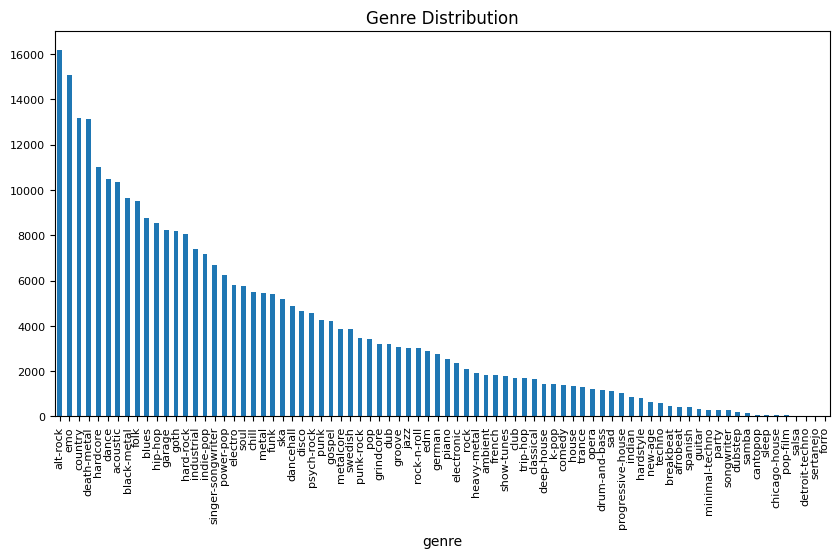

In [5]:
df['genre'].value_counts().plot(kind='bar', figsize=(10, 5), title='Genre Distribution', fontsize=8);

<Axes: xlabel='genre'>

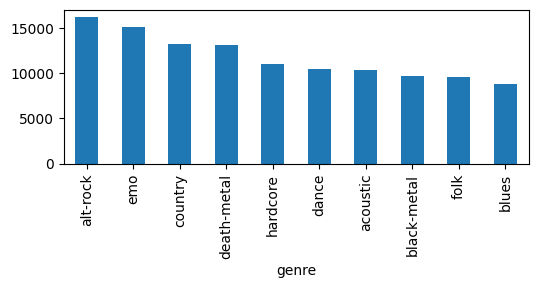

In [49]:
top_genres = list(df['genre'].value_counts().head(10).index)
df = df[df['genre'].isin(top_genres)]

df['genre'].value_counts().plot(kind='bar', figsize=(6,2))

# Models

- [NGram](#NGram)
- [Character RNN - per genre](#Character-RNN---per-genre)
- [Character RNN - general](#Character-RNN---general)
- [Token RNN](#Token-RNN)
- [Word RNN](#Word-RNN)


![title](../assets/images/imported/model_architectures_task2.png)

## NGram

In [ ]:
if not os.path.exists('models'):
    os.makedirs('models')

def generate_model(genre, n = 3):
    # load existing model if it exists
    path = os.path.join(MODELS_PATH, 'ngram', f'{genre}_model.pkl')
    if(os.path.exists(path)):
        print(f"Model for genre '{genre}' already exists. Loading from file.")
        with open(f'models/{genre}_model.pkl', 'rb') as fin:
            model = pickle.load(fin)
        return model
    
    print(f"Creating model for genre '{genre}'")
    text = df[df['genre'] == genre]['lyrics'].values
    text = ' '.join(text)
    
    
    sents = sent_tokenize(text)
    tokenized_sents = [word_tokenize(sent) for sent in sents]
    
    # now we convert the padded sentences into a flat list of tokens - including the padding.
    padded_sents = [list(pad_sequence(sent, pad_left=True, 
                                 left_pad_symbol="<s>",
                                 pad_right=True, right_pad_symbol="</s>", n=2))
                    for sent in tokenized_sents]
    
    
    model = MLE(n) # the parameter is the n of our n-grams 
    train_data, padded_sents = padded_everygram_pipeline(n, tokenized_sents)
    
    model.fit(train_data, padded_sents)

    # save
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'wb') as fout:
        pickle.dump(model, fout)
    
    return model

In [28]:
def generate_text(model, num_words, text_seed):
    content = text_seed.split()
    
    for _ in range(num_words - len(content)):
        if len(content) >= model.order:
            next_word = model.generate(text_seed=content[-(model.order - 1):]) 
        else:
            model.generate(text_seed=content)
        content.append(next_word)
        if (next_word == '</s>'):
            break
    
    return " ".join(content)

In [33]:
generated_dict = {}
for idx, genre in enumerate(top_genres):
    model = generate_model(genre, n=3)
    generated_songs = []
    for _ in range(GENERATIONS_PER_GENRE):
        generated_songs.append(generate_text(model, 100, "<s> I am"))
    generated_dict[genre]=generated_songs

with open(os.path.join(GENERATION_PATH, 'ngram_generated.json'), "w", encoding="utf-8") as f:
    json.dump(generated_dict, f, ensure_ascii=False, indent=2)

Model for genre 'alt-rock' already exists. Loading from file.
Model for genre 'emo' already exists. Loading from file.
Model for genre 'country' already exists. Loading from file.
Model for genre 'death-metal' already exists. Loading from file.
Model for genre 'hardcore' already exists. Loading from file.
Model for genre 'dance' already exists. Loading from file.
Model for genre 'acoustic' already exists. Loading from file.
Model for genre 'black-metal' already exists. Loading from file.
Model for genre 'folk' already exists. Loading from file.
Model for genre 'blues' already exists. Loading from file.


### Find short generated entries

In [64]:
file_name = os.path.join(GENERATION_PATH, 'ngram_generated.json')
with open(file_name, 'r', encoding='utf-8') as f:
    generated_data = json.load(f)

generated_df = pd.DataFrame([
    {'genre': genre, 'text': text} 
    for genre, texts in generated_data.items() 
    for text in texts
])

# find entries where text contains less or equal to 5 words
generated_df['word_count'] = generated_df['text'].apply(lambda x: len(x.split()))
generated_df = generated_df[generated_df['word_count'] <= 5]
generated_df

,genre,text,word_count
32,alt-rock,<s> I am ? </s>,5
53,alt-rock,<s> I am ? </s>,5
83,alt-rock,<s> I am ? </s>,5
110,emo,<s> I am ! </s>,5
379,death-metal,<s> I am ! </s>,5
572,dance,<s> I am ! </s>,5
609,acoustic,<s> I am ! </s>,5
614,acoustic,<s> I am ... </s>,5
859,folk,<s> I am ? </s>,5
871,folk,<s> I am ? </s>,5


## Character RNN - per genre

In [40]:
# Hyperparameters
batch_size = 128
seq_length = 50
n_epochs = 5
hidden_size = 256
n_layers = 1
lr = 0.001

In [38]:
class CharDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, index):
        return (self.data[index:index+self.seq_length],
                self.data[index+1:index+self.seq_length+1])
    
class CharGenreRNN(nn.Module):
    def __init__(self, tokens, n_hidden, n_layers):
        super(CharGenreRNN, self).__init__()
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        self.embedding = nn.Embedding(len(tokens), n_hidden)
        self.rnn = nn.LSTM(n_hidden, n_hidden, n_layers, batch_first=True)
        self.fc = nn.Linear(n_hidden, len(tokens))

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        weight = next(self.parameters())
        return (weight.new_zeros(self.n_layers, batch_size, self.n_hidden).to(weight.device),
                weight.new_zeros(self.n_layers, batch_size, self.n_hidden).to(weight.device))

In [58]:
def process_text(texts, dict_path):
    text = unidecode.unidecode('\n'.join(texts))
    chars = sorted(set(text))
    int2char = {i: ch for i, ch in enumerate(chars)}
    char2int = {ch: i for i, ch in int2char.items()}
    
    with open(dict_path, 'w') as f:
        json.dump({'int2char': int2char, 'char2int': char2int, 'chars': chars}, f)

    encoded = np.array([char2int[ch] for ch in text])
    return encoded, int2char, char2int, chars

def generate_text(
        model, 
        int2char, 
        char2int, 
        size=300,
        prime='The ', 
        temperature=0.8):
    
    model.eval()
    chars = [ch for ch in prime]
    h = model.init_hidden(1)

    for ch in prime:
        char_tensor = torch.tensor([[char2int[ch]]], dtype=torch.long)
        _, h = model(char_tensor, h)

    last_char = prime[-1]
    for _ in range(size):
        char_tensor = torch.tensor([[char2int[last_char]]], dtype=torch.long)
        out, h = model(char_tensor, h)
        out_dist = out.view(-1).div(temperature).exp()
        top_char = torch.multinomial(out_dist, 1)[0]
        last_char = int2char[str(top_char.item())]
        chars.append(last_char)

    return ''.join(chars)

In [52]:
def train_rnn_for_genre(
        genre, 
        texts, 
        seq_length=100, 
        batch_size=128, 
        n_epochs=5, 
        hidden_size=128, 
        n_layers=2, 
        lr=0.001):
    
    print(f"Training for genre: {genre}")
    dict_path = os.path.join(MODELS_PATH, 'rnn_per_genre' f'{genre}_dict.json')
    model_path = os.path.join(MODELS_PATH, 'rnn_per_genre', f'{genre}_model.pth')
    os.makedirs(os.path.dirname(model_path), exist_ok=True)

    encoded, _, _, chars = process_text(texts, dict_path)
    dataset = CharDataset(encoded, seq_length)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = CharGenreRNN(chars, hidden_size, n_layers)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(n_epochs):
        total_loss = 0
        model.train()
        with alive_bar(len(dataloader), title=f'{genre}: Epoch {epoch+1}/{n_epochs}') as bar:
            for x, y in dataloader:
                h = model.init_hidden(x.size(0))
                model.zero_grad()
                output, h = model(x, h)
                loss = criterion(output.transpose(1, 2), y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                bar()
        print(f"{genre}: Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")
        torch.save(model.state_dict(), model_path)
    print(f"Model for {genre} saved to {model_path}")

In [ ]:
for genre in top_genres:
    texts = df[df['genre'] == genre]['lyrics'].tolist()
    train_rnn_for_genre(genre, texts, seq_length=seq_length, batch_size=batch_size, n_epochs=n_epochs, hidden_size=hidden_size, n_layers=n_layers, lr=lr)

In [ ]:
generated_dict = {}
for genre in top_genres:
    print(f"Generating text for genre: {genre}")
    dict_path = os.path.join(MODELS_PATH, 'rnn_per_genre', f'{genre}_dict.json')
    model_path = os.path.join(MODELS_PATH, 'rnn_per_genre', f'{genre}_model.pth')
    
    with open(dict_path, 'r') as f:
        dict = json.load(f)
    
    int2char = dict['int2char']
    char2int = dict['char2int']
    
    model = CharGenreRNN(dict['chars'], hidden_size, n_layers)
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    
    generated_texts = []
    for _ in range(GENERATIONS_PER_GENRE):
        generated_texts.append(generate_text(model, int2char, char2int, size=100, prime='The ', temperature=0.8))

    generated_dict[genre] = generated_texts
    
with open(os.path.join(GENERATION_PATH, 'char_rnn_per_genre_generated.json'), 'w', encoding='utf-8') as f:
    json.dump(generated_dict, f, ensure_ascii=False, indent=2)

## Character RNN - general

In [ ]:
all_text = "".join(df["lyrics"].tolist())
chars = sorted(list(set(all_text)))
print(f"Found {len(chars)} unique characters")

Found 94 unique characters


In [ ]:
char2idx = {ch: i+1 for i, ch in enumerate(chars)}
char2idx["<PAD>"] = 0      # reserve index=0 for padding
char2idx["<EOS>"] = len(char2idx)
idx2char = {i: ch for ch, i in char2idx.items()}

vocab_size = len(char2idx)
print(f"Vocabulary size: {vocab_size}")
idx2char

Vocabulary size: 96


{1: ' ',
 2: '!',
 3: '"',
 4: '#',
 5: '$',
 6: '%',
 7: '&',
 8: "'",
 9: '(',
 10: ')',
 11: '*',
 12: '+',
 13: ',',
 14: '-',
 15: '.',
 16: '/',
 17: '0',
 18: '1',
 19: '2',
 20: '3',
 21: '4',
 22: '5',
 23: '6',
 24: '7',
 25: '8',
 26: '9',
 27: ':',
 28: ';',
 29: '<',
 30: '=',
 31: '>',
 32: '?',
 33: '@',
 34: 'A',
 35: 'B',
 36: 'C',
 37: 'D',
 38: 'E',
 39: 'F',
 40: 'G',
 41: 'H',
 42: 'I',
 43: 'J',
 44: 'K',
 45: 'L',
 46: 'M',
 47: 'N',
 48: 'O',
 49: 'P',
 50: 'Q',
 51: 'R',
 52: 'S',
 53: 'T',
 54: 'U',
 55: 'V',
 56: 'W',
 57: 'X',
 58: 'Y',
 59: 'Z',
 60: '[',
 61: '\\',
 62: ']',
 63: '^',
 64: '_',
 65: 'a',
 66: 'b',
 67: 'c',
 68: 'd',
 69: 'e',
 70: 'f',
 71: 'g',
 72: 'h',
 73: 'i',
 74: 'j',
 75: 'k',
 76: 'l',
 77: 'm',
 78: 'n',
 79: 'o',
 80: 'p',
 81: 'q',
 82: 'r',
 83: 's',
 84: 't',
 85: 'u',
 86: 'v',
 87: 'w',
 88: 'x',
 89: 'y',
 90: 'z',
 91: '{',
 92: '|',
 93: '}',
 94: '~',
 0: '<PAD>',
 95: '<EOS>'}

In [ ]:
all_genres = sorted(df["genre"].unique().tolist())
genre2idx = {g: i for i, g in enumerate(all_genres)}
idx2genre = {i: g for g, i in genre2idx.items()}

num_genres = len(genre2idx)
print(f"Number of genres: {num_genres}")
idx2genre

Number of genres: 10


{0: 'acoustic',
 1: 'alt-rock',
 2: 'black-metal',
 3: 'blues',
 4: 'country',
 5: 'dance',
 6: 'death-metal',
 7: 'emo',
 8: 'folk',
 9: 'hardcore'}

In [ ]:
# convert chars to idx of char in mapping
def lyric_to_int_sequence(lyric: str, char2idx: dict, max_seq_len: int):
    seq = [char2idx.get(ch, 0) for ch in lyric]
    seq.append(char2idx["<EOS>"])
    if len(seq) >= max_seq_len:
        return torch.tensor(seq[:max_seq_len], dtype=torch.long)
    else:
        # pad on the right with zeros
        padded = seq + [0] * (max_seq_len - len(seq))
        return torch.tensor(padded, dtype=torch.long)


In [ ]:
max_seq_len = 800

lyric_seqs = []
genre_labels = []

for _, row in df.iterrows():
    lyric_tensor = lyric_to_int_sequence(row["lyrics"], char2idx, max_seq_len)
    genre_tensor = torch.tensor(genre2idx[row["genre"]], dtype=torch.long)
    lyric_seqs.append(lyric_tensor)
    genre_labels.append(genre_tensor)

lyric_seqs = torch.stack(lyric_seqs)       # shape (N, max_seq_len)
genre_labels = torch.stack(genre_labels)

lyric_seqs[:5], genre_labels[:5]

(tensor([[26, 20,  1,  ...,  1, 82, 79],
         [53, 72, 69,  ...,  0,  0,  0],
         [58, 79, 85,  ..., 65, 78, 68],
         [ 9, 40, 85,  ..., 85, 73, 84],
         [49, 85, 84,  ..., 83,  1, 76]], device='cuda:0'),
 tensor([0, 0, 0, 0, 0], device='cuda:0'))

In [ ]:
from torch.utils.data import Dataset, DataLoader

class LyricsGenreDataset(Dataset):
    def __init__(self, lyric_seqs, genre_labels):
        assert lyric_seqs.size(0) == genre_labels.size(0)
        self.lyric_seqs = lyric_seqs
        self.genre_labels = genre_labels

    def __len__(self):
        return self.lyric_seqs.size(0)

    def __getitem__(self, idx):
        return {
            "input_seq": self.lyric_seqs[idx],     # full length includes padding
            "genre": self.genre_labels[idx]
        }

# Instantiate and create a DataLoader
dataset = LyricsGenreDataset(lyric_seqs, genre_labels)
batch_size = 64


dataloader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    # shuffle=True, 
    drop_last=True,
    # generator=g
)

In [67]:
import torch
import torch.nn as nn

class CharRNN(nn.Module):
    def __init__(self, 
                 vocab_size: int, 
                 num_genres: int, 
                 char_emb_dim: int = 128, 
                 genre_emb_dim: int = 32, 
                 hidden_size: int = 512, 
                 num_layers: int = 2, 
                 dropout: float = 0.3):
        
        super().__init__()
        self.vocab_size = vocab_size
        self.num_genres = num_genres
        self.char_emb_dim = char_emb_dim
        self.genre_emb_dim = genre_emb_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.char_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=char_emb_dim, padding_idx=0)
        self.genre_emb = nn.Embedding(num_embeddings=num_genres, embedding_dim=genre_emb_dim)

        # LSTM: input size = char_emb_dim + genre_emb_dim
        self.lstm = nn.LSTM(
            input_size=char_emb_dim + genre_emb_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(in_features=hidden_size, out_features=vocab_size)

    def forward(self, input_seq: torch.LongTensor, genre_ids: torch.LongTensor):
        B, seq_len = input_seq.size()

        # embed chars
        e_chars = self.char_emb(input_seq) # [B, seq_len, char_emb_dim]

        # embed genre
        e_genre = self.genre_emb(genre_ids)  # [B, genre_emb_dim]

        # expand genre over all chars
        e_genre_exp = e_genre.unsqueeze(1).repeat(1, seq_len, 1) # [B, seq_len, genre_emb_dim]

        # Concat genre + genre embedding
        rnn_input = torch.cat([e_chars, e_genre_exp], dim=2) # [B, seq_len, char_emb_dim + genre_emb_dim]

        # Feed in lstm network
        h_out, (h_n, c_n) = self.lstm(rnn_input)

        logits = self.fc_out(h_out)

        return logits


In [ ]:
char_emb_dim  = 128
genre_emb_dim = 16
hidden_size   = 512
num_layers    = 2
dropout       = 0.3
learning_rate = 1e-3
num_epochs    = 30

In [ ]:
model = CharRNN(
    vocab_size=vocab_size,
    num_genres=num_genres,
    char_emb_dim=char_emb_dim,
    genre_emb_dim=genre_emb_dim,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout
)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [ ]:
from tqdm import tqdm

history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    print(f"Epoch {epoch+1}/{num_epochs}")

    for batch_idx, batch in enumerate(tqdm(dataloader, desc=f"Training Epoch {epoch+1}")):
        input_seq = batch["input_seq"]
        genre_ids = batch["genre"]

        logits = model(input_seq, genre_ids)

        logits_flat = logits[:, :-1, :].reshape(-1, vocab_size)
        targets_flat = input_seq[:, 1:].reshape(-1)

        loss = criterion(logits_flat, targets_flat)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # tqdm.write(f"Batch {batch_idx+1}/{len(dataloader)} — Loss: {loss.item():.4f}")

    history.append(total_loss)

Epoch 1/30


Training Epoch 1: 100%|██████████| 1832/1832 [08:52<00:00,  3.44it/s]


Epoch 2/30


Training Epoch 2: 100%|██████████| 1832/1832 [08:54<00:00,  3.43it/s]


Epoch 3/30


...

Training Epoch 28: 100%|██████████| 1832/1832 [08:55<00:00,  3.42it/s]


Epoch 29/30


Training Epoch 29: 100%|██████████| 1832/1832 [08:53<00:00,  3.44it/s]


Epoch 30/30


Training Epoch 30: 100%|██████████| 1832/1832 [08:55<00:00,  3.42it/s]


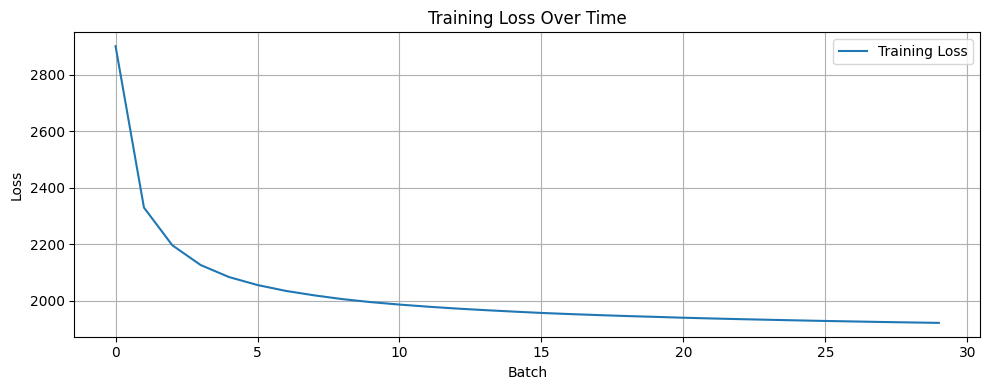

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history, label='Training Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
import torch.nn.functional as F

def generate_lyrics(
    model: CharRNN,
    start_char: str,
    genre: str,
    char2idx: dict,
    idx2char: dict,
    genre2idx: dict,
    max_length: int = 500,
    temperature: float = 1.0,
):
    model.eval()
    with torch.no_grad():
        input_idx = torch.tensor([[char2idx.get(start_char, 0)]], dtype=torch.long)
        genre_idx = torch.tensor([genre2idx[genre]], dtype=torch.long)

        generated_chars = [start_char]

        hidden_state, cell_state = None, None

        for _ in range(max_length):
            e_char = model.char_emb(input_idx)
            e_gen  = model.genre_emb(genre_idx)
            e_gen_exp = e_gen.unsqueeze(1)
            rnn_input = torch.cat([e_char, e_gen_exp], dim=2)

            if hidden_state is None and cell_state is None:
                output, (hidden_state, cell_state) = model.lstm(rnn_input)
            else:
                output, (hidden_state, cell_state) = model.lstm(rnn_input, (hidden_state, cell_state))

            logits = model.fc_out(output.squeeze(1))
            logits = logits / temperature # apply temperature before selecting next token

            probs = F.softmax(logits, dim=-1)

            # select next char
            next_char_idx = torch.multinomial(probs, num_samples=1).item()
            next_char = idx2char[next_char_idx]

            if next_char == "<EOS>":
                print('Found eos token')
                break

            generated_chars.append(next_char)

            input_idx = torch.tensor([[next_char_idx]], dtype=torch.long)

    return "".join(generated_chars)

In [65]:
model_path = os.path.join(MODELS_PATH, 'character_rnn_bundle.pth')

In [ ]:
import os
os.makedirs('data/models', exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'num_genres': num_genres,
    'char_emb_dim': char_emb_dim,
    'genre_emb_dim': genre_emb_dim,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'dropout': dropout,
    'char2idx': char2idx,
    'idx2char': idx2char,
    'genre2idx': genre2idx
}

torch.save(checkpoint, model_path)

In [68]:
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
char2idx_loaded = checkpoint['char2idx']
idx2char_loaded = checkpoint['idx2char']
genre2idx_loaded = checkpoint['genre2idx']

# Reconstruct model
model_loaded = CharRNN(
    vocab_size=checkpoint['vocab_size'],
    num_genres=checkpoint['num_genres'],
    char_emb_dim=checkpoint['char_emb_dim'],
    genre_emb_dim=checkpoint['genre_emb_dim'],
    hidden_size=checkpoint['hidden_size'],
    num_layers=checkpoint['num_layers'],
    dropout=checkpoint['dropout']
)

model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

CharRNN(
  (char_emb): Embedding(96, 128, padding_idx=0)
  (genre_emb): Embedding(10, 16)
  (lstm): LSTM(144, 512, num_layers=2, batch_first=True, dropout=0.3)
  (fc_out): Linear(in_features=512, out_features=96, bias=True)
)

In [69]:
start = ""
prompt_genre = "country"
lyric = generate_lyrics(model_loaded, start, prompt_genre, char2idx_loaded, idx2char_loaded, genre2idx_loaded, max_length=400, temperature=0.7)
print(f"--- Generated ({prompt_genre}) ---\n{lyric}")

--- Generated (country) ---
on Shook up my cab and trying to walk into the sky Something in there is nothing About to make it all over And the pain of a position So I can do it anyway But we're just another song It won't be long enough to stop till it breaks It's passing over And that's when it happens then Took a picture of a million different ways Oh, I was looking for something to wait And I finally found out the way that


In [ ]:
generated_dict = {}
for genre in top_genres:
    print(f"Generating text for genre: {genre}")
    generated_texts = []
    for _ in range(GENERATIONS_PER_GENRE):
        generated_texts.append(generate_lyrics(model_loaded, start, genre, char2idx_loaded, idx2char_loaded, genre2idx_loaded, max_length=100, temperature=0.8))
    generated_dict[genre] = generated_texts

with open(os.path.join(GENERATION_PATH, 'char_rnn_generated.json'), 'w', encoding='utf-8') as f:
    json.dump(generated_dict, f, ensure_ascii=False, indent=2)


## Token RNN

In [ ]:
from tokenizers import Tokenizer, pre_tokenizers, models, trainers, normalizers
from tokenizers.pre_tokenizers import Metaspace

tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Metaspace()
trainer = trainers.BpeTrainer(vocab_size=2000, special_tokens=["<PAD>", "<UNK>", "<BOS>", "<EOS>"])

In [ ]:
texts = df['lyrics'].tolist()
tokenizer.train_from_iterator(texts, trainer)

In [ ]:
df["bpe_tokens"] = df["lyrics"].apply(lambda x: tokenizer.encode(x).ids)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["genre_id"] = le.fit_transform(df["genre"])  # genre_id is int
genre_size = len(le.classes_)
genre_size

10

In [ ]:
tokenized_lyrics = df["bpe_tokens"].tolist()  # list of lists of BPE token IDs
genre_ids = df["genre_id"].tolist()           # list of genre int IDs

vocab_size = tokenizer.get_vocab_size()
pad_id = tokenizer.token_to_id("<PAD>")
bos_id = tokenizer.token_to_id("<BOS>")
eos_id = tokenizer.token_to_id("<EOS>")

SEQ_LEN = 64

len(tokenized_lyrics), len(genre_ids)

(117265, 117265)

In [ ]:
from torch.utils.data import DataLoader
class LyricsDataset(torch.utils.data.Dataset):
    def __init__(self, tokenized_lyrics, genres, seq_len, pad_id, bos_id, eos_id):
        self.samples = []
        for tokens, genre in zip(tokenized_lyrics, genres):
            tokens = [bos_id] + tokens + [eos_id]
            for i in range(0, len(tokens) - 1, seq_len):
                input_seq = tokens[i:i+seq_len]
                target_seq = tokens[i+1:i+1+seq_len]

                if len(input_seq) < seq_len:
                    input_seq += [pad_id] * (seq_len - len(input_seq))
                if len(target_seq) < seq_len:
                    target_seq += [pad_id] * (seq_len - len(target_seq))
                
                self.samples.append((input_seq, target_seq, genre))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_seq, target_seq, genre = self.samples[idx]
        return torch.tensor(input_seq), torch.tensor(target_seq), torch.tensor(genre)
    
dataset = LyricsDataset(
    tokenized_lyrics=tokenized_lyrics,
    genres=genre_ids,
    seq_len=SEQ_LEN,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id
)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    # shuffle=True,
    drop_last=True  # makes training more efficient
)

In [ ]:
import torch.nn as nn

class TokenRNN(nn.Module):
    def __init__(self, vocab_size, genre_size, embedding_dim, genre_embedding_dim, hidden_dim):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.genre_embedding = nn.Embedding(genre_size, genre_embedding_dim)
        self.rnn = nn.LSTM(embedding_dim + genre_embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, genre):
        token_embeds = self.token_embedding(x)  # (batch, seq_len, embed_dim)
        genre_embeds = self.genre_embedding(genre).unsqueeze(1)  # (batch, 1, genre_embed_dim)
        genre_repeated = genre_embeds.expand(-1, x.size(1), -1)  # Repeat for each timestep
        rnn_input = torch.cat([token_embeds, genre_repeated], dim=2)
        output, _ = self.rnn(rnn_input)
        return self.fc(output)

In [ ]:
model = TokenRNN(
    vocab_size = tokenizer.get_vocab_size(),
    genre_size = genre_size,
    embedding_dim = 128,
    genre_embedding_dim = 16,
    hidden_dim = 256
)

In [ ]:
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30

In [ ]:
history = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for input_seq, target_seq, genre in dataloader:
        logits = model(input_seq, genre)
        loss = loss_fn(logits.view(-1, vocab_size), target_seq.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1} done. Total Loss={total_loss:.4f}")
    history.append(total_loss)

Epoch 1 done. Total Loss=98836.5975
Epoch 2 done. Total Loss=90910.5359
Epoch 3 done. Total Loss=89088.0602
Epoch 4 done. Total Loss=88104.5885
Epoch 5 done. Total Loss=87468.5831
Epoch 6 done. Total Loss=87029.4219
Epoch 7 done. Total Loss=86706.0083
Epoch 8 done. Total Loss=86452.8179
Epoch 9 done. Total Loss=86247.9818
Epoch 10 done. Total Loss=86077.6651
Epoch 11 done. Total Loss=85935.9302
Epoch 12 done. Total Loss=85817.3384
Epoch 13 done. Total Loss=85714.5916
Epoch 14 done. Total Loss=85626.4533
Epoch 15 done. Total Loss=85548.3600
Epoch 16 done. Total Loss=85480.0979
Epoch 17 done. Total Loss=85417.6923
Epoch 18 done. Total Loss=85361.7944
Epoch 19 done. Total Loss=85311.2951
Epoch 20 done. Total Loss=85264.7345
Epoch 21 done. Total Loss=85222.0450
Epoch 22 done. Total Loss=85183.4472
Epoch 23 done. Total Loss=85147.1727
Epoch 24 done. Total Loss=85112.8217
Epoch 25 done. Total Loss=85080.8346
Epoch 26 done. Total Loss=85051.8037
Epoch 27 done. Total Loss=85022.4350
Epoch 28 d

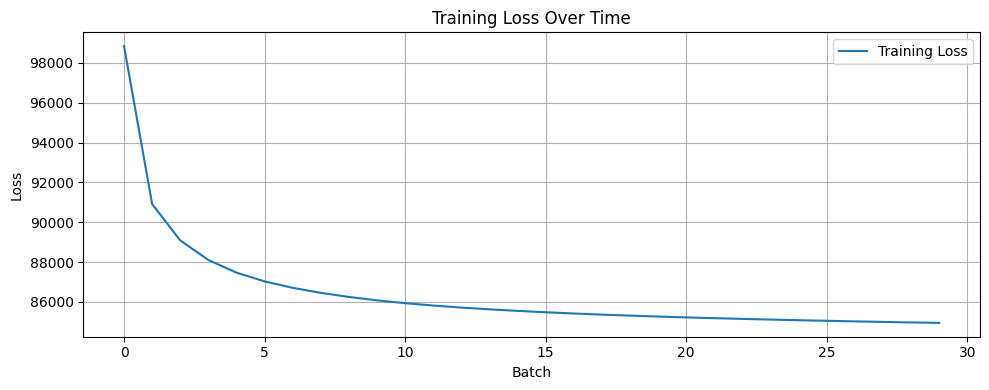

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history, label='Training Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from tokenizers import decoders
tokenizer.decoder = decoders.Metaspace()

In [ ]:
def generate(model, genre_id, tokenizer, max_len=100, temperature=1.0, min_len=0):
    model.eval()
    input_seq = torch.tensor([[bos_id]])
    genre_tensor = torch.tensor([genre_id])

    generated = []
    hidden = None

    count = 0
    for _ in range(max_len):
        # print(genre_tensor.shape, input_seq.shape)
        logits = model(input_seq, genre_tensor)
        logits = logits[:, -1, :] / temperature
        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        token_id = next_token.item()

        if token_id == eos_id:
            if count >= min_len:
                break
        else: 
            count += 1

        generated.append(token_id)
        input_seq = next_token  # shape (1, 1)

    return tokenizer.decode(generated)

In [ ]:
generate(model, 4, tokenizer)

"Everybody thinks you know, think we gettin' on the end opt conseche You got you calleditin' (He again All the failures Gee I need? I'm not Shouldin' Wantations Let 'em waiting for my life ain't where we have Your grage in the light to us meet. Yeah, Saches when I cannot bellinsenteen scars Cause people attable steps on it, go round your not to be mine I can't spend the long with"

In [ ]:
model_path = os.path.join(MODELS_PATH, 'token_rnn_bundle_2k.pth')

In [ ]:
import os
os.makedirs('data/models', exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'vocab_size': tokenizer.get_vocab_size(),
    'genre_size': genre_size,
    'embedding_dim': 128,
    'genre_embedding_dim': 16,
    'hidden_dim': 256,
    'tokenizer_json': tokenizer.to_str(),  # include tokenizer as string
}

torch.save(checkpoint, model_path)

In [ ]:
import torch
from tokenizers import Tokenizer
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))

tokenizer_loaded = Tokenizer.from_str(checkpoint['tokenizer_json'])

model_loaded = TokenRNN(
    vocab_size=checkpoint['vocab_size'],
    genre_size=checkpoint['genre_size'],
    embedding_dim=checkpoint['embedding_dim'],
    genre_embedding_dim=checkpoint['genre_embedding_dim'],
    hidden_dim=checkpoint['hidden_dim']
)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

bos_id = tokenizer_loaded.token_to_id("<BOS>")
eos_id = tokenizer_loaded.token_to_id("<EOS>")

In [ ]:
generated_dict = {}
for idx, genre in enumerate(le.classes_):
    generated_songs = []
    for _ in range(GENERATIONS_PER_GENRE):
        generated_songs.append(generate(model_loaded, idx, tokenizer_loaded, min_len=50, max_len=300))
    generated_dict[genre]=generated_songs

with open(os.path.join(GENERATION_PATH, "token_rnn_generated.json"), "w", encoding="utf-8") as f:
    json.dump(generated_dict, f, ensure_ascii=False, indent=2)

## Word RNN

In [ ]:
from sklearn.model_selection import train_test_split
n = 64000
# select n random samples from the DataFrame
df, _ = train_test_split(df, train_size=n, stratify=df['genre'], random_state=42)
df

,track_id,genre,lyrics,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
63539,63ppBrc53uoYiSDViI4xVH,alt-rock,Come this way That's what I hear him say From ...,0.469,0.942,-3.181,0.0671,0.03800,0.008730,0.0588,0.8440,88.031
63151,6spaGIZEfeDYlgAupMI34k,alt-rock,Your eyes follow like a spotlight Two eyes lik...,0.370,0.855,-3.232,0.2900,0.00354,0.000000,0.3720,0.6500,185.791
148420,1qqwvyRR7sAmDreHKtqsM8,death-metal,A mind consumed with anger From the womb I was...,0.546,0.992,-5.281,0.1000,0.00017,0.044200,0.2410,0.1700,103.511
64866,5gVIaHdxCyV8Vi7nhYVF2y,country,"One horse town, restless soul Wondering where ...",0.616,0.879,-3.718,0.0408,0.00923,0.000145,0.3180,0.6720,119.016
12138,7nR9M7Wx8HNnnhkyVRTMJa,black-metal,The pale blue fire of glittering spires ablaze...,0.276,0.516,-7.653,0.0367,0.00040,0.899000,0.1700,0.1700,139.813
...,...,...,...,...,...,...,...,...,...,...,...,...
35526,44Imwj5wbjpdq1XNLEMkPH,emo,Please don't call unless you have to Say I'll ...,0.636,0.713,-11.023,0.0474,0.39400,0.082400,0.0848,0.0993,110.057
109050,3yt4cxIbpVUF7iaFOvV16X,blues,"The daylight breaks, a picture show of endless...",0.415,0.196,-19.691,0.0305,0.69800,0.000035,0.2680,0.3010,103.298
163016,0RzW2gEcXyldSEmxsbgul9,blues,We've got it simple Cause we've got a band And...,0.394,0.770,-8.654,0.0257,0.78300,0.853000,0.4000,0.4780,106.040
252756,48PcyEr2j0OstqkOHW5VEy,alt-rock,"His love endures forever Yes, His love endures...",0.185,0.790,-8.629,0.1140,0.33100,0.019900,0.9720,0.3120,58.557


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
def tokenize_text_nltk(text: str) -> str:
    tokens = word_tokenize(text)
    return " ".join(tokens).lower()

df["lyrics"] = df["lyrics"].astype(str).apply(tokenize_text_nltk)

In [ ]:
df['tokens'] = df['lyrics'].apply(lambda x: x.split())
df['tokens']

63539     [come, this, way, that, 's, what, i, hear, him...
63151     [your, eyes, follow, like, a, spotlight, two, ...
148420    [a, mind, consumed, with, anger, from, the, wo...
64866     [one, horse, town, ,, restless, soul, wonderin...
12138     [the, pale, blue, fire, of, glittering, spires...
                                ...                        
35526     [please, do, n't, call, unless, you, have, to,...
109050    [the, daylight, breaks, ,, a, picture, show, o...
163016    [we, 've, got, it, simple, cause, we, 've, got...
252756    [his, love, endures, forever, yes, ,, his, lov...
265396    [trouble, in, mind, ,, i, 'm, blue, but, i, wo...
Name: tokens, Length: 64000, dtype: object

In [ ]:
from collections import Counter
min_count = 5

special_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
special_tokens_lookup = {token: idx for idx, token in enumerate(special_tokens)}

word_counts = Counter(word for tokens in df['tokens'] for word in tokens if word not in special_tokens)
filtered_words = sorted([word for word, count in word_counts.items() if count >= min_count])

vocab = special_tokens + filtered_words
# vocab = special_tokens + sorted(set(word for tokens in df['tokens'] for word in tokens) - set(special_tokens))
# print(vocab)
word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)
list(word2idx.items())[:40], vocab_size, special_tokens_lookup

([('<PAD>', 0),
  ('<SOS>', 1),
  ('<EOS>', 2),
  ('<UNK>', 3),
  ('!', 4),
  ('#', 5),
  ('$', 6),
  ('%', 7),
  ('&', 8),
  ("'", 9),
  ("''", 10),
  ("'03", 11),
  ("'06", 12),
  ("'07", 13),
  ("'09", 14),
  ("'49", 15),
  ("'51", 16),
  ("'57", 17),
  ("'59", 18),
  ("'60s", 19),
  ("'62", 20),
  ("'63", 21),
  ("'64", 22),
  ("'65", 23),
  ("'67", 24),
  ("'68", 25),
  ("'69", 26),
  ("'70s", 27),
  ("'72", 28),
  ("'73", 29),
  ("'75", 30),
  ("'76", 31),
  ("'80s", 32),
  ("'81", 33),
  ("'82", 34),
  ("'83", 35),
  ("'84", 36),
  ("'85", 37),
  ("'86", 38),
  ("'87", 39)],
 34831,
 {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3})

In [ ]:
corpus = df["tokens"].tolist()
corpus[0][:10]

['come', 'this', 'way', 'that', "'s", 'what', 'i', 'hear', 'him', 'say']

In [ ]:
from gensim.models import FastText

ft_model = FastText(
        sentences=corpus,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
)

In [ ]:
similar_words = ft_model.wv.most_similar("heart", topn=10)
for word, score in similar_words:
    print(f"{word}: {score:.4f}")

heart/: 0.8604
heartn: 0.8491
heart's: 0.8434
heart-to-heart: 0.8336
heart-on-my-heart: 0.8298
heartss: 0.8249
eart: 0.8243
halfheart: 0.8210
beefheart: 0.8133
earnheart: 0.8124


In [ ]:
embedding_dim = 100
emb_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
for token, idx in word2idx.items():
    if token in ft_model.wv:
        emb_matrix[idx] = ft_model.wv[token]
    else:
        # random uniform values
        emb_matrix[idx] = np.random.uniform(-0.05, 0.05, embedding_dim).astype(np.float32)

emb_matrix_tensor = torch.tensor(emb_matrix)
emb_matrix

array([[-0.03558419, -0.01497867,  0.01079354, ..., -0.02442387,
        -0.02110754,  0.02552651],
       [-0.01115203,  0.02220931,  0.0151113 , ..., -0.01069211,
         0.00210085, -0.02061321],
       [-0.00606444,  0.00960593,  0.00958758, ..., -0.02712106,
         0.00824997, -0.05601006],
       ...,
       [-0.03698318, -0.00874377, -0.05511294, ..., -0.20461941,
        -0.07334539, -0.0300245 ],
       [ 0.2032799 ,  0.0165729 ,  0.01985553, ..., -0.25207797,
        -0.25882038,  0.02896352],
       [ 0.12563324,  0.07152395, -0.01782018, ..., -0.29304558,
        -0.12078999,  0.12193182]], dtype=float32)

In [ ]:
all_genres = sorted(df["genre"].unique().tolist())
genre2idx = {g: i for i, g in enumerate(all_genres)}
idx2genre = {i: g for g, i in genre2idx.items()}

num_genres = len(genre2idx)
print(f"Number of genres: {num_genres}")
idx2genre

Number of genres: 10


{0: 'acoustic',
 1: 'alt-rock',
 2: 'black-metal',
 3: 'blues',
 4: 'country',
 5: 'dance',
 6: 'death-metal',
 7: 'emo',
 8: 'folk',
 9: 'hardcore'}

In [ ]:
unk_idx = special_tokens_lookup.get('<UNK>')
pad_idx = special_tokens_lookup.get('<PAD>')
sos_idx = special_tokens_lookup.get('<SOS>')
eos_idx = special_tokens_lookup.get('<EOS>')

def lyric_to_int_sequence(lyric: list, word2idx: dict, max_seq_len: int, pad=True):
    seq = [word2idx.get(token, unk_idx) for token in lyric]
    seq = [sos_idx] + seq + [eos_idx]
    if len(seq) >= max_seq_len or not pad:
        return torch.tensor(seq[:max_seq_len], dtype=torch.long)
    elif(pad):
        # pad on the right with zeros
        padded = seq + [pad_idx] * (max_seq_len - len(seq))
        return torch.tensor(padded, dtype=torch.long)

unk_idx, pad_idx, sos_idx, eos_idx

(3, 0, 1, 2)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

df.reset_index(inplace=True)

df['joined_tokens'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

df['genre_id'] = df['genre'].map(genre2idx)

vectorizer = CountVectorizer(
    vocabulary=word2idx,
    lowercase=False,
    tokenizer=lambda s: s.split(),   # split on spaces exactly
    preprocessor=None,
    token_pattern=None             # disable the default pattern
)

# vectorizer = CountVectorizer(vocabulary=word2idx)

X = vectorizer.fit_transform(df['joined_tokens'])  # shape: (num_songs, vocab_size)
print(X.shape)

freq_matrix = torch.zeros(num_genres, vocab_size)

for genre_id in range(num_genres):
    indices = df[df['genre_id'] == genre_id].index
    genre_matrix = X[indices].sum(axis=0)
    freq_matrix[genre_id] = torch.tensor(genre_matrix).squeeze()


freq_matrix, freq_matrix.shape

(64000, 34831)


(tensor([[ 0.,  0.,  0.,  ...,  1.,  1.,  8.],
         [ 0.,  0.,  0.,  ...,  1.,  1.,  6.],
         [ 0.,  0.,  0.,  ...,  0.,  0., 23.],
         ...,
         [ 0.,  0.,  0.,  ...,  2.,  1.,  2.],
         [ 0.,  0.,  0.,  ...,  5.,  0.,  0.],
         [ 0.,  0.,  0.,  ...,  5.,  1.,  3.]], device='cuda:0'),
 torch.Size([10, 34831]))

In [ ]:
epsilon = 1e-8
global_counts = freq_matrix.sum(dim=0)  # (vocab_size,)
global_total = global_counts.sum()
global_probs = global_counts / (global_total + epsilon)  # (vocab_size,)
global_probs

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.1347e-06, 6.2406e-07,
        2.5530e-06], device='cuda:0')

In [ ]:
log_prob_matrix = torch.zeros_like(freq_matrix)

for genre_id in range(num_genres):
    genre_probs = freq_matrix[genre_id] / (freq_matrix[genre_id].sum() + epsilon)
    log_prob_matrix[genre_id] = torch.log(genre_probs + epsilon) - torch.log(global_probs + epsilon)

log_prob_matrix

tensor([[ 0.0000,  0.0000,  0.0000,  ..., -0.4646,  0.1261,  0.7966],
        [ 0.0000,  0.0000,  0.0000,  ..., -1.0263, -0.4355, -0.0611],
        [ 0.0000,  0.0000,  0.0000,  ..., -4.7403, -4.1496,  2.3078],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ..., -0.2217, -0.3133, -1.0278],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.2495, -4.1496, -5.5463],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.7414, -0.2608, -0.5727]],
       device='cuda:0')

In [ ]:
genre_bias = {
    genre: log_prob_matrix[genre_id]
    for genre, genre_id in genre2idx.items()
}
genre_bias

{'acoustic': tensor([ 0.0000,  0.0000,  0.0000,  ..., -0.4646,  0.1261,  0.7966],
        device='cuda:0'),
 'alt-rock': tensor([ 0.0000,  0.0000,  0.0000,  ..., -1.0263, -0.4355, -0.0611],
        device='cuda:0'),
 'black-metal': tensor([ 0.0000,  0.0000,  0.0000,  ..., -4.7403, -4.1496,  2.3078],
        device='cuda:0'),
 'blues': tensor([ 0.0000,  0.0000,  0.0000,  ..., -4.7403,  1.0738, -0.3229],
        device='cuda:0'),
 'country': tensor([ 0.0000,  0.0000,  0.0000,  ..., -0.2098,  0.3810, -5.5463],
        device='cuda:0'),
 'dance': tensor([ 0.0000,  0.0000,  0.0000,  ...,  0.0328,  0.6235, -1.8551],
        device='cuda:0'),
 'death-metal': tensor([ 0.0000,  0.0000,  0.0000,  ..., -0.4955, -4.1496, -5.5463],
        device='cuda:0'),
 'emo': tensor([ 0.0000,  0.0000,  0.0000,  ..., -0.2217, -0.3133, -1.0278],
        device='cuda:0'),
 'folk': tensor([ 0.0000,  0.0000,  0.0000,  ...,  1.2495, -4.1496, -5.5463],
        device='cuda:0'),
 'hardcore': tensor([ 0.0000,  0.0000,

In [ ]:
from torch.utils.data import Dataset, DataLoader
import random

class LyricsDataset(Dataset):
    def __init__(self, word_seq, genre_labels, word2idx, genre2idx, context_len=20, samples_per_lyric=5, max_seq_len=400):
        assert len(word_seq) == len(genre_labels)
        self.word_seq = word_seq
        self.genre_labels = genre_labels

        self.samples = []
        for words, genre in zip(word_seq, genre_labels):
            tokens = lyric_to_int_sequence(words, word2idx, max_seq_len=400, pad=False)

            n_windows = len(tokens) - context_len
            if n_windows <= 0:
                continue  # too short, skip

            # pick up to samples_per_lyric random start positions
            starts = random.sample(range(n_windows),
                                   k=min(samples_per_lyric, n_windows))

            for i in starts:
                inp = tokens[i : i + context_len]
                tgt = tokens[i + context_len]
                gix = genre2idx[genre]
                self.samples.append((inp, tgt, gix))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_seq, target_token, genre_idx = self.samples[idx]
        return (
            torch.tensor(input_seq, dtype=torch.long),
            torch.tensor(target_token, dtype=torch.long),
            torch.tensor(genre_idx, dtype=torch.long)
        )
    
dataset = LyricsDataset(df['tokens'], df['genre'], word2idx, genre2idx, samples_per_lyric=10)

batch_size = 64
dataloader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    # shuffle=True, 
    drop_last=True,
    
)

In [134]:
import torch
import torch.nn as nn

class WordRNN(nn.Module):
    def __init__(self, 
                 pretrained_emb_matrix: torch.Tensor,
                 num_genres,
                 genre_emb_dim,
                 hidden_dim,
                 num_layers):
        super().__init__()
        self.vocab_size, self.word_emb_dim = pretrained_emb_matrix.shape
        self.num_genres = num_genres
        self.genre_emb_dim = genre_emb_dim
        self.hidden_size = hidden_dim

        self.word_emb = nn.Embedding.from_pretrained(pretrained_emb_matrix, freeze=False, padding_idx=pad_idx)
        self.genre_emb = nn.Embedding(num_embeddings=num_genres, embedding_dim=genre_emb_dim)

        self.lstm = nn.LSTM(
            input_size=self.word_emb_dim  + genre_emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_seq: torch.LongTensor, genre_ids: torch.LongTensor, hidden=None):
        _, seq_len = input_seq.size()
        
        emb_words = self.word_emb(input_seq) 
        emb_genre = self.genre_emb(genre_ids)

        emb_genre_exp = emb_genre.unsqueeze(1).repeat(1, seq_len, 1)

        rnn_input = torch.cat([emb_words, emb_genre_exp], dim=2)

        output, hidden = self.lstm(rnn_input, hidden)

        logits = self.fc(output[:, -1, :])
        return logits, hidden

In [ ]:
GENRE_EMB_DIM = 32
HIDDEN_DIM = 256
N_LAYERS = 2
LR = 0.001
EPOCHS = 50

In [ ]:
model = WordRNN(
    pretrained_emb_matrix=emb_matrix_tensor,
    num_genres=num_genres,
    genre_emb_dim=GENRE_EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=N_LAYERS,
)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [ ]:
from tqdm import tqdm
import torch.nn.functional as F

history = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    print(f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc=f"Training Epoch {epoch+1}")):
        input_seqs, target_tokens, genre_idxs = batch

        optimizer.zero_grad()
        logits, _ = model(input_seqs, genre_idxs)

        # print(input_seqs.size(), target_tokens.size(), logits.size())

        loss = criterion(logits, target_tokens)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"loss={total_loss}")
    history.append(total_loss)


Epoch 1/50


Training Epoch 1: 100%|██████████| 9990/9990 [02:07<00:00, 78.53it/s]


loss=56579.384536504745
Epoch 2/50


Training Epoch 2: 100%|██████████| 9990/9990 [02:07<00:00, 78.21it/s]


loss=49969.29304909706
Epoch 3/50


...

loss=23565.25703752041
Epoch 49/50


Training Epoch 49: 100%|██████████| 9990/9990 [02:05<00:00, 79.48it/s]


loss=23469.45793402195
Epoch 50/50


Training Epoch 50: 100%|██████████| 9990/9990 [02:05<00:00, 79.46it/s]

loss=23388.797640800476


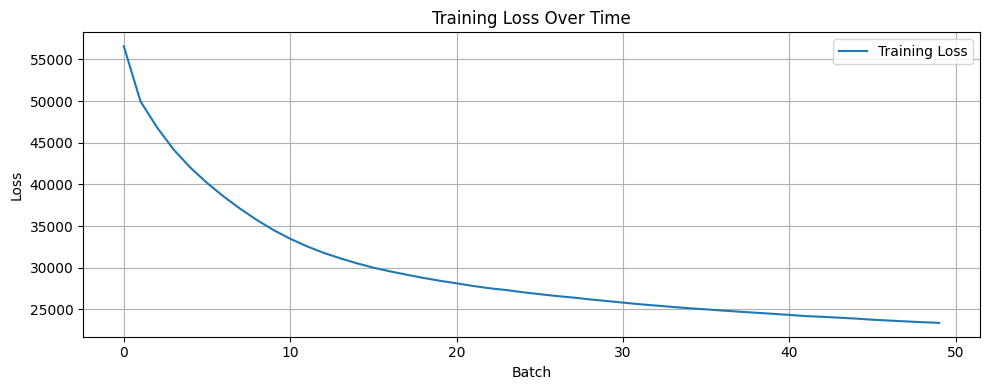

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history, label='Training Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model_path = os.path.join(MODELS_PATH, 'word_rnn_bundle_64k.pth')

In [ ]:
import os
os.makedirs('data/models', exist_ok=True)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'vocab_size': model.vocab_size,
    'word_emb_dim': model.word_emb_dim,
    'num_genres': model.num_genres,
    'genre_emb_dim': model.genre_emb_dim,
    'hidden_size': model.hidden_size,
    'num_layers': model.lstm.num_layers,
    'genre2idx': genre2idx,
    'idx2word': idx2word,
    'word2idx': word2idx,
    'pad_idx': pad_idx,  # include this if needed during reloading
    'pretrained_emb_matrix': emb_matrix_tensor,  # you can optionally save the matrix itself
    'genre_bias': genre_bias, 
}

torch.save(checkpoint, model_path)

In [ ]:
import torch.nn.functional as F
def generate_text(model, genre, genre2idx, idx2word, word2idx,
                  max_len=50, context_len=20, start_token='<SOS>', temperature=1.0, alpha=0.5, min_len=0):
    model.eval()
    genre_id = torch.tensor([genre2idx[genre]], dtype=torch.long)

    input_seq = [word2idx.get(start_token, 0)] * context_len

    generated_words = []

    hidden = None

    count = 0
    for _ in range(max_len):
        input_tensor = torch.tensor([input_seq], dtype=torch.long)

        with torch.no_grad():
            logits, hidden = model(input_tensor, genre_id, hidden)

        logits = logits.squeeze() / temperature  # apply temperature

        # disable unk
        logits[unk_idx] = -float('inf')

        biased_logits = logits + alpha * genre_bias[genre].to(logits.device)
        
        probs = F.softmax(biased_logits, dim=-1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()

        if next_token_id == eos_idx:
            if count >= min_len:
                break
        else: 
            count += 1
            generated_words.append(idx2word.get(next_token_id, '<UNK>'))

        # Update input sequence window
        input_seq = input_seq[1:] + [next_token_id]

    return ' '.join(generated_words)

In [ ]:
def top_genre_words(genre, genre_bias, idx2word, topk=10):
    log_probs = genre_bias[genre]
    top_indices = torch.topk(log_probs, topk).indices
    return [idx2word[i.item()] for i in top_indices]

# Example:
print(top_genre_words("dance", genre_bias, idx2word))

['arrr', 'weh', 'bruk', 'oya', 'cle', 'backaz', 'yuuhh', 'leh', 'wey', 'rollout']


In [ ]:
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
word2idx_loaded = checkpoint['word2idx']
idx2word_loaded = checkpoint['idx2word']
genre2idx_loaded = checkpoint['genre2idx']
pad_idx = checkpoint['pad_idx']
unk_idx = checkpoint['word2idx'].get('<UNK>', 0)
eos_idx = checkpoint['word2idx'].get('<EOS>', 0)
vocab_size = checkpoint['vocab_size']
genre_bias = checkpoint['genre_bias']

model_loaded = WordRNN(
    pretrained_emb_matrix=checkpoint['pretrained_emb_matrix'],
    num_genres=checkpoint['num_genres'],
    genre_emb_dim=checkpoint['genre_emb_dim'],
    hidden_dim=checkpoint['hidden_size'],
    num_layers=checkpoint['num_layers'],
)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

WordRNN(
  (word_emb): Embedding(34831, 100, padding_idx=0)
  (genre_emb): Embedding(10, 32)
  (lstm): LSTM(132, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=256, out_features=34831, bias=True)
)

In [ ]:
generated_dict = {}
for idx, genre in enumerate(genre2idx_loaded):
    generated_songs = []
    for _ in range(GENERATIONS_PER_GENRE):
        generated_songs.append(generate_text(model_loaded, genre, genre2idx_loaded, idx2word_loaded, word2idx_loaded, max_len=200, alpha=2, min_len=15))
    generated_dict[genre]=generated_songs

with open(os.path.join(GENERATION_PATH, "word_alpha2_rnn_generated.json"), "w", encoding="utf-8") as f:
    json.dump(generated_dict, f, ensure_ascii=False, indent=2)

In [ ]:
import torch
import torch.nn.functional as F
import random

def inspect_top_predictions(model, dataset, idx2word, word2idx, idx2genre, genre_bias, unk_idx, eos_idx, temperature=1.0, alpha=0.5, top_k=10, context_len=20):
    model.eval()

    input_seq, target_token, genre_idx = dataset[random.randint(0, len(dataset) - 1)]
    seq = input_seq.tolist() if isinstance(input_seq, torch.Tensor) else list(input_seq)

    context_words = [idx2word.get(int(tok), '<UNK>') for tok in seq]
    genre_name = idx2genre[int(genre_idx)]
    true_word = idx2word.get(int(target_token), '<UNK>')

    print(f"Genre: {genre_name}")
    print("Context:", ' '.join(context_words))
    print(f"True next word: {true_word}\n")

    device = next(model.parameters()).device
    input_tensor = torch.tensor([seq], dtype=torch.long, device=device)
    genre_id = torch.tensor([int(genre_idx)], dtype=torch.long, device=device)

    # Run forward pass
    with torch.no_grad():
        logits, _ = model(input_tensor, genre_id, None)

    raw_logits = logits[0, -1, :] if logits.dim() == 3 else logits[0]

    # Apply temperature scaling and genre bias
    scaled_logits = raw_logits / temperature
    scaled_logits[unk_idx] = -float('inf')
    bias = genre_bias[genre_name].to(scaled_logits.device)
    biased_logits = scaled_logits + alpha * bias

    # Compute softmax and top-k predictions
    probs = F.softmax(biased_logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, top_k)

    # Print top predictions
    print(f"Top {top_k} predictions:")
    for rank, (idx, prob) in enumerate(zip(top_indices.tolist(), top_probs.tolist()), 1):
        print(f"  {rank}. {idx2word.get(idx, '<UNK>'):<15} (p={prob:.4f})")

    # Print true next word probability
    print(f"\nProbability of correct next word ('{true_word}'): {probs[int(target_token)]:.4f}")

    return top_indices, top_probs


In [ ]:
inspect_top_predictions(model_loaded, dataset, idx2word, word2idx, idx2genre, genre_bias, unk_idx, eos_idx, alpha=2);

Genre: emo
Context: know you 're scared to move away from the people that led your astray but this is not a test
True next word: of

Top 10 predictions:
  1. but             (p=0.4193)
  2. of              (p=0.2075)
  3. and             (p=0.1160)
  4. or              (p=0.0454)
  5. you             (p=0.0428)
  6. so              (p=0.0409)
  7. i               (p=0.0203)
  8. just            (p=0.0101)
  9. for             (p=0.0099)
  10. that            (p=0.0076)

Probability of correct next word ('of'): 0.2075


In [ ]:
songs_per_genre=10
alphas = np.arange(0.0, 10.25, 0.25)
generated_dict_alphas = {}
for a in alphas:
    generated_dict = {}
    for idx, genre in enumerate(genre2idx_loaded):
        generated_songs = []
        for _ in range(songs_per_genre):
            generated_songs.append(generate_text(model_loaded, genre, genre2idx_loaded, idx2word_loaded, word2idx_loaded, max_len=200, alpha=a, min_len=15))
        generated_dict[genre]=generated_songs
    generated_dict_alphas[a] = generated_dict

with open(os.path.join(GENERATION_PATH, "word_alphavariants_rnn_generated.json"), "w", encoding="utf-8") as f:
    json.dump(generated_dict, f, ensure_ascii=False, indent=2)

# Evaluation

## Classifier

In [50]:
df.reset_index(drop=True, inplace=True)
label = 'genre'
text_col = 'lyrics'

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(ngram_range=(1, 1), 
                             min_df=1, 
                             max_df=0.5, ##
                             lowercase=True,
                             stop_words=None,
                             tokenizer=str.split)

X_tfidf = tfidf_vect.fit_transform(df[text_col])

X_tfidf.shape

/var/lib/luttkusfe95323/.local/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



(117265, 267163)

In [52]:
X = X_tfidf
y = df[label]
X.shape, y.shape

((117265, 267163), (117265,))

In [53]:
from sklearn.model_selection import train_test_split

# define holdout
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=test_size,
                                                    stratify = y,
                                                    random_state=43)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((93812, 267163), (23453, 267163), (93812,), (23453,))

In [54]:
from sklearn.linear_model import SGDClassifier
import joblib

model_path = os.path.join(MODELS_PATH, 'tfidf_sgd_classifier.pth')
if os.path.exists(model_path):
    print("Loading existing model...")
    clf = joblib.load(model_path)
else:
    print("Training new model...")
    clf = SGDClassifier(loss='hinge')
    clf.fit(X_train, y_train)
    joblib.dump(clf, model_path)
clf

Loading existing model...


SGDClassifier()

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

fig_counter = 0
def show_conf_matrix(y_true, y_pred, labels=None, title=None, export_path=None, show_report=False, show_legend=False, scale=1.0, show_fig_counter=True):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report_text = None
    if show_report:
        report_text = classification_report(y_true, y_pred, labels=labels)

    if show_fig_counter:
        global fig_counter
        fig_counter += 1
    
    base_width = 14 if show_report or show_legend else 10
    base_height = 8 + (0.5 if show_report else 0)
    fig_width = base_width * scale
    fig_height = base_height * scale
    plt.figure(figsize=(fig_width, fig_height))

    if show_report:
        from matplotlib.gridspec import GridSpec
        gs = GridSpec(1, 2, width_ratios=[2, 1])
        ax0 = plt.subplot(gs[0])
        ax1 = plt.subplot(gs[1])
    else:
        ax0 = plt.gca()
        ax1 = None

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax0)
    ax0.set_xlabel('Predicted')
    ax0.set_ylabel('True')
    ax0.set_title(title or 'Confusion Matrix')

    # Add classification report text
    if show_report and ax1:
        ax1.axis('off')  # Hide axes
        ax1.text(0, 1, report_text, fontsize=12 * scale, family='monospace', va='top')

    if show_legend:
        if labels is None:
            labels = sorted(set(y_true) | set(y_pred))
        legend_text = '\n'.join(f'{i}: {label}' for i, label in enumerate(labels))
        # Show legend on right or bottom if report is also shown
        if ax1:
            ax1.text(0, 0, legend_text, fontsize=12 * scale, family='monospace', va='bottom')
        else:
            plt.gcf().text(1.02, 0.5, legend_text, fontsize=12 * scale, family='monospace', va='center')

    if show_fig_counter:
        plt.figtext(0.5, 0.01, f"Fig. {fig_counter}" + f": {title}" if title else "", ha='center', va='bottom', fontsize=12 * scale, style='italic')

    if export_path:
        plt.tight_layout()
        plt.savefig(export_path)
        plt.close()
    else:
        plt.tight_layout()
        plt.show()
                
    

Train accuracy:  64.05%


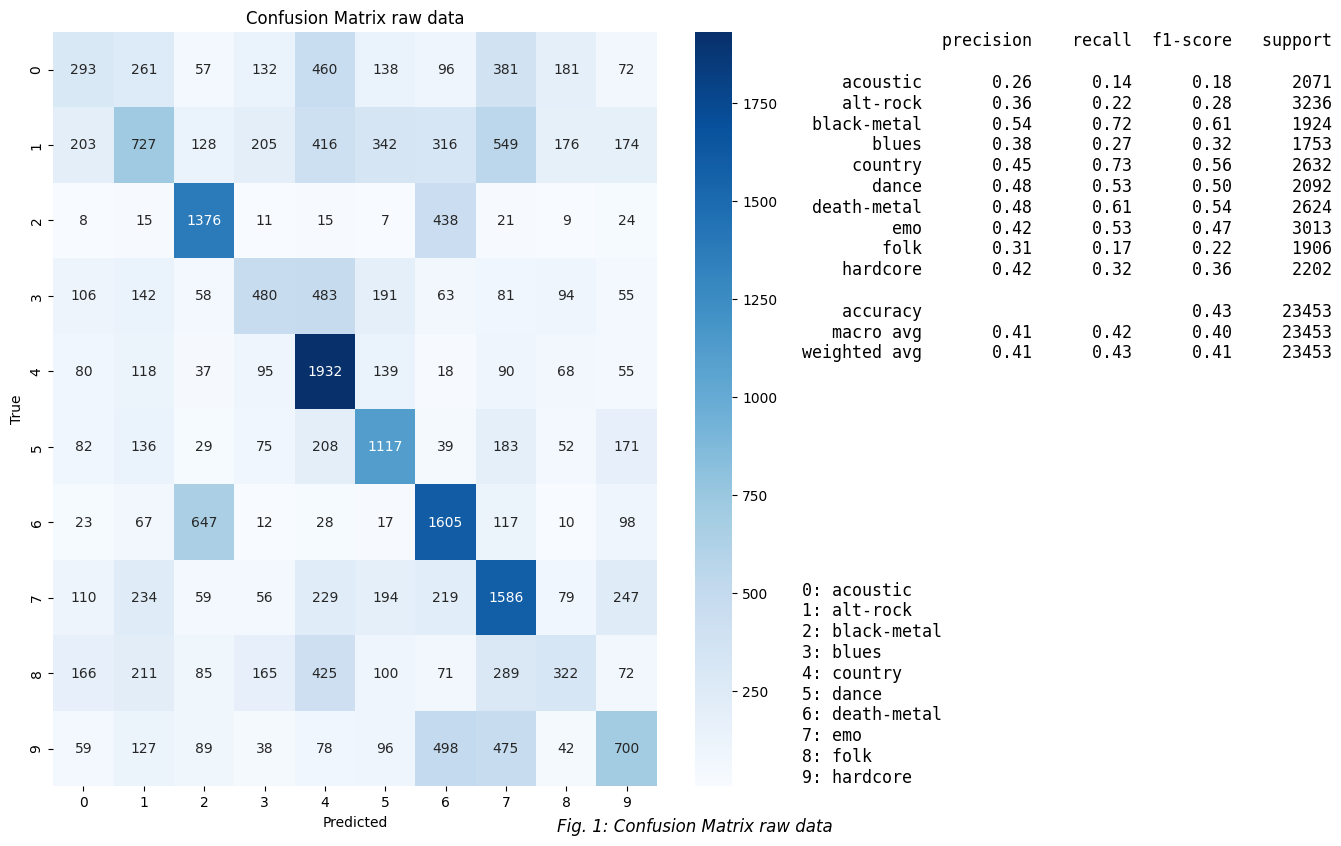

In [40]:
from sklearn.metrics import accuracy_score

y_test_pred = clf.predict(X_test)
y_train_pred = clf.predict(X_train)

print(f"Train accuracy: {accuracy_score(y_train, y_train_pred)*100:6.2f}%")

show_conf_matrix(
    y_test, y_test_pred, 
    labels=clf.classes_, 
    title='Confusion Matrix raw data', 
    show_report=True, show_legend=True)

The overall performance of the TF-IDF-based genre classifier shows a clear diagonal trend in the confusion matrix, with an accuracy of 43% on the test set. This suggests that, while the classifier captures genre-specific patterns to some extent, there is still substantial overlap between genres. Notably, death-metal is frequently misclassified as black-metal (recall for death-metal: 0.61; precision for black-metal: 0.54), likely due to overlapping textual features between the two genres. Conversely, black-metal is often correctly identified (recall: 0.72), achieving one of the highest precision and recall scores, although it is sometimes confused with death-metal, highlighting the genre proximity in text-based representations.

Acoustic music appears particularly challenging for the model, with predictions widely distributed across other genres (recall: 0.14; precision: 0.26), indicating a lack of distinct textual features that set it apart. Similarly, alt-rock exhibits confusion, often being misclassified as emo (recall: 0.22), though it still retains a focused cluster of correct predictions between the two (precision: 0.36; emo precision: 0.42), suggesting partial overlap in descriptors or themes.

Overall, while the model shows promise with genres like black-metal (F1-score: 0.61), country (F1-score: 0.56), and death-metal (F1-score: 0.54), which have higher recall and precision, more nuanced genres like acoustic and folk (folk recall: 0.17; acoustic F1-score: 0.18) suffer from lower discriminability in the TF-IDF space, possibly due to their more general or overlapping language use.

## Classifier on generated

In [42]:
models = ['ngram', 'char_rnn_per_genre', 'char_rnn', 'token_rnn', 'word_alpha2_rnn']

file_names = [os.path.join(GENERATION_PATH, f"{model}_generated.json") for model in models]
file_names

['data/generations/ngram_generated.json',
 'data/generations/char_rnn_per_genre_generated.json',
 'data/generations/char_rnn_generated.json',
 'data/generations/token_rnn_generated.json',
 'data/generations/word_alpha2_rnn_generated.json']

In [43]:
for file_name in file_names:
    with open(file_name, 'r', encoding='utf-8') as f:
        generated_data = json.load(f)

    # base name with not _generated.json ending
    model_name = os.path.basename(file_name).replace('_generated.json', '').replace('_', ' ').title()
    
    # file structure: {genre: [list of generated texts]}
    data = []
    for genre, texts in generated_data.items():
        for text in texts:
            data.append({'genre': genre, 'text': text})

    generated_df = pd.DataFrame(data)
    generated_df.sort_values(by='genre', inplace=True)

    X = tfidf_vect.transform(generated_df['text'])
    y_pred = clf.predict(X)
    generated_df['predicted_genre'] = y_pred

    show_conf_matrix(
        generated_df['genre'], generated_df['predicted_genre'], 
        labels=clf.classes_, 
        title=f'Confusion Matrix {model_name}', 
        show_report=True, show_legend=True,
        scale=0.6,
        export_path=os.path.join(IMAGES_PATH_EXPORTED, f"{model_name}_confusion_matrix.png")
    )

![Ngram confusion matrix](../assets/images/imported/conf_matrices/Ngram_confusion_matrix.png)

Figure 2 presents the classification results for the NGram-based model (n=3), where a separate classifier is trained for each class. Similar to Figure 1 (raw data), the confusion matrix reveals a distinct diagonal trend, and the overall accuracy remains at 43%, indicating comparable performance between the two approaches.

Unlike the classifier trained on raw data, which distributes predictions more uniformly across classes, this model shows a marked tendency to predict certain genres more frequently - specifically acoustic (precision: 0.34), black-metal (precision: 0.29), and blues (precision: 0.34). This indicates that these genres exhibit more general or widely shared lyrical features, leading the classifier to match their patterns with lyrics from a broader range of genres.

Despite these biases, the classifier performs moderately well across most genres, with generally balanced recall scores. However, alt-rock (recall: 0.07) and folk (recall: 0.08) stand out as underperforming. This likely reflects the more diffuse or stylistically diverse language within these genres, making it more difficult for the model to generate consistent, genre-specific lexical patterns.

As with the classifier trained on raw data, a strong similarity is observed between death-metal and black-metal. However, the confusion is more asymmetrical here: black-metal is misclassified as death-metal in only 3 out of 100 cases, whereas 48 out of 100 true death-metal samples are predicted as black-metal. Overall, black-metal achieves the highest recall (0.95), indicating that its linguistic features are particularly distinctive and consistently captured by the model.

**Example** \
True Genre: `black-metal`, Predicted Genre: `black-metal`

*Note: Line break were added afterwards*

> I am fearing the most ever known  
> Buried like vanquished reason  
> Death in her ashen malice  
> And in the air Hung and thin ,  
> 
> and guilt Will no longer welcomes you to see  
> I gouged my eyes Unto the bloodstained walls  
> 
> The air reeks of cowardice Casting this hex  
> You will forever be In belligerence  
> In belligerence In belligerence In belligerence  
> 
> I count the snakes coming out from the above  
> The fusion of life and death means nothing  
> All the blood of gross hematuria  
> From the underground thrives  
> ( but who cares what 's right He will ask no 

These lyrics illustrate why the classifier may be highly confident when predicting black-metal. Words such as `fearing`, `Buried`, `Death`, as well as more vivid terms like `bloodstainded`and `belligerence`, contribute to a distinctive and easily separable TF-IDF vector for this genre.

Although acoustic remains a challenging genre, performance improves relative to the raw data classifier (precision: 0.26; recall: 0.14), with the n-gram model achieving a precision of 0.34 and a recall of 0.48. Country has the best classification with a F1 score of 0.65.

Since no minimum length was enforced for generated texts, it is theoretically possible for sequences to end immediately after the given start token, often with just a `</s>` or a single token preceding it. However, in practice, this was rare: out of 1,000 generated samples (100 per genre), only 5 texts contained five or fewer tokens (including start and end markers), meaning that in the vast majority of cases, the generation produced at least some words that can be classified.

![Char RNN Per Genre confusion matrix](../assets/images/imported/conf_matrices/Char%20Rnn%20Per%20Genre_confusion_matrix.png)


Training a genre-specific character-level RNN leads to improved performance in the downstream TF-IDF-based genre classification task, achieving an accuracy of 40%, as shown in Figure 3.

As with the raw classification results, predictions are more evenly distributed, and precision scores are relatively balanced across classes. Notably, the strong relationship between black-metal and death-metal persists, with both genres being frequently confused - each misclassified as the other in over 20 out of 100 samples.

These two genres, along with country (F1-score: 0.51), achieve the highest classification performance, with black-metal and death-metal reaching F1-scores of 0.60 and 0.49, respectively. This suggests that the RNN-generated text retains key stylistic and lexical patterns characteristic of these genres, making them more distinguishable in the TF-IDF space.

![Char RNN confusion matrix](../assets/images/imported/conf_matrices/Char%20Rnn_confusion_matrix.png)

Training a single character-level RNN with genre as an input condition results in a significant drop in classification performance, with a low accuracy of 16%, as shown by the absence of a strong diagonal in the confusion matrix.

The strong connection between black-metal and death-metal remains evident, with both genres being mutually misclassified in approximately 30% of cases. Notably, other genres are rarely predicted for these two, indicating that the model still captures some shared stylistic features between them.

Death-metal also shows a precision of 0.16, partly inflated by frequent misclassification of hardcore as death-metal in 25% of instances.

In contrast, folk (precision: 0.00) and acoustic (precision: 0.05) are almost never predicted correctly. This suggests that the RNN struggles to generate distinct, genre-typical features for these categories, resulting in their representations being too generic or ambiguous for the TF-IDF classifier to distinguish effectively.

![Char RNN confusion matrix](../assets/images/imported/conf_matrices/Token%20Rnn_confusion_matrix.png)

Figure 5 presents the classification results for an RNN trained on a Byte Pair Encoding (BPE) vocabulary of 2,000 tokens. Compared to the character-level RNN, this model achieves a higher overall accuracy of 23%.

Hardcore shows a significant improvement (recall: 0.42) compared to the character-level model (recall: 0.04), indicating that the BPE-based vocabulary helps capture more genre-specific patterns for this category.

In contrast, alt-rock and blues experience a performance decline, with only 8 and 7 out of 100 samples correctly classified, respectively. This suggests that BPE segmentation may obscure finer stylistic cues needed for distinguishing these genres.

Black-metal also sees its lowest recall to date (0.16), with a notable shift in predictions toward death-metal (precision: 0.33). This reinforces the previously observed lexical overlap between the two genres, with the model favoring the more general or dominant class when ambiguity arises.

**Example** \
True Genre: `acoustic`, Predicted Genre: `emo`

> Hoat When they like you're more caping Ladased that last year ARRE O little hours face Love is what my brain and papone All I don't change of sometimes nobody I dowed out of what's mine

This example highlights a key limitation of lyrics-only approaches. Without access to beat structure, tempo, or the emotional tone conveyed by the audio, classifying such lyrics becomes a difficult task, even for humans. The text contains few, if any, clear indicators of the intended genre, making it challenging to infer the correct classification based solely on the words. To address this, the next model introduces a new hyperparameter designed to favor genre-specific vocabulary during generation.

![Char RNN confusion matrix](../assets/images/imported/conf_matrices/Word%20Alpha2%20Rnn_confusion_matrix.png)

In this model, setting alpha=2 - applying a genre-specific bias vector scaled by 2 to the logits before the softmax layer - encourages the generation of more genre-distinctive words. This adjustment is intended to steer the generation process toward more exploratory use of rare but genre-specific vocabulary.

With an accuracy of 56%, this model achieves the highest performance among all tested variants. Black-metal (recall: 1.00) and country (recall: 0.97) are classified with near-perfect accuracy, indicating that these genres exhibit highly distinctive lexical patterns that are well captured in the generated text.

On the other hand, acoustic (recall: 0.34), alt-rock (recall: 0.31), and folk (recall: 0.18) show the weakest results, suggesting greater ambiguity and less genre-specific language, which likely increases classifier uncertainty.

A strong asymmetry is observed between death-metal and black-metal: 71 out of 100 true death-metal samples are misclassified as black-metal (death-metal recall: 0.29), while black-metal is rarely confused in return. This highlights a dominant lexical overlap in one direction, reinforcing the classifier’s tendency to favor black-metal when uncertain.

### Alpha tuning

In [ ]:
file_name = os.path.join(GENERATION_PATH, 'word_alphavariants_rnn_generated.json')
with open(file_name, 'r', encoding='utf-8') as f:
    generated_data = json.load(f)

data = []
for alpha, genres in generated_data.items():
    for genre, texts in genres.items():
        for text in texts:
            data.append({'alpha': float(alpha), 'genre': genre, 'text': text})

generated_df = pd.DataFrame(data)
generated_df.sort_values(by=['alpha', 'genre'], inplace=True)


In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score

alpha_values = generated_df['alpha'].unique()
conf_matrices = {}
accuracies = []

generated_df['prediction'] = None

for a in alpha_values:
    subset = generated_df[generated_df['alpha'] == a]
    generated_dict = subset.groupby('genre')['text'].apply(list).to_dict()

    X_gen = tfidf_vect.transform([text for texts in generated_dict.values() for text in texts])
    y_gen_pred = clf.predict(X_gen)
    y_gen_true = [genre for genre, texts in generated_dict.items() for _ in texts]

    subset_indices = subset.index
    if len(subset_indices) != len(y_gen_pred):
        raise ValueError("Mismatch in number of predictions and subset size")

    generated_df.loc[subset_indices, 'prediction'] = y_gen_pred

    cm = confusion_matrix(y_gen_true, y_gen_pred, labels=clf.classes_)
    conf_matrices[a] = cm
    accuracies.append((a, accuracy_score(y_gen_true, y_gen_pred)))

![Alpha tuning animation](../assets/images/imported/alpha_tuning.gif)

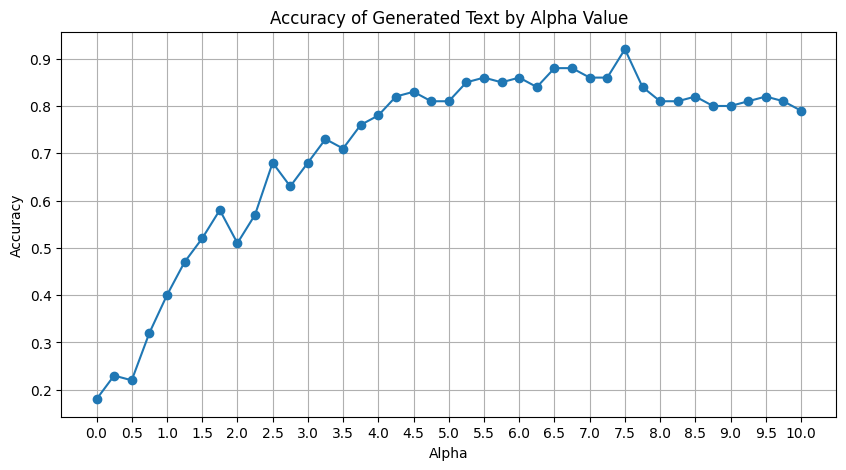

In [28]:
# plot accuracies
plt.figure(figsize=(10, 5))
plt.plot([a[0] for a in accuracies], [a[1] for a in accuracies], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy of Generated Text by Alpha Value')
plt.xticks(np.arange(0, max(alpha_values) + 0.5, 0.5))
plt.grid(True)
plt.show()

Varying the alpha-value, used to scale the genre-specific bias vector added to the logits, directly impacts classification accuracy. Increasing α encourages the model to favor strongly genre-specific words during generation, resulting in more distinguishable feature distributions in the TF-IDF space.

At alpha=0, the model behaves like a standard conditional RNN without genre bias, yielding an accuracy of 18%, comparable to the character-level RNN with genre input (16%). As alpha increases, accuracy improves in diminishing increments, reaching a peak of 92% at alpha=7.5, before plateauing around 80%. This trend shows that stronger genre biases help the model generate more discriminative text—up to a point, beyond which oversaturation may harm coherence.

**Example** (alpha=0.0, index=1) \
True Genre: `acoustic`, Predicted Genre: `country`

> to sittin ' on the other brown street i said , he said god , i ran out of the the first old york i had new might rid mind a hundred put a cold , i still did n't grow so i was bless my soul friend i drank the whole day in the slouch box , i kissed lonesome the smell as i hit the small muddy i pulled a little away a fool i did i was veteran ... i 'm a mess i turned the five wide spot silverado yeah i caught me loose i made her with my scent i tried to fit her deep i wan na be i razor skin every captive in my chevy skin i paint my bills as long winning eyes strung my face oh ooo i must be the ending of the day about every hello go crashing i was going to show up i was eighteen with a thousand boy closed i was eighteen flown ' piece of five fine but we were n't felt my place reachin ' at the negative land ah fake out the place honey the night is the end now darlin na well

Despite being generated as acoustic, the lyrics contain phrases such as `brown street`, `old york`, `drank the whole day`, and `muddy`, which are strongly associated with country music. Still, with 18% accuracy, it performs better than random guessing across 10 genres.

**Example** (alpha=2.0, index=868) \
True Genre: `death-metal`, Predicted Genre: `black-metal`

> touch me into the storm . been stuck on the waves using the day like a piece of truth we must leave the grip of the crowd we did n't have wasted on their watched the sky was the day , the right thing to reach the day of the time in the past the rhetoric for the day we were the the prosperity by the side we know the face of the dead the infinite people we shall uncover vultures guide the rain we accursed faces the night we shall devour the endless consciousness we were in the silence the land doing now when each curse we stood still swallowed by the clouds we pulled deep into the ground a revolt chant the chant we 've earned the end before forgotten will turn to immeasurable rats all this world the shell trace of an empty corroded the a day the sons are the forced nation the throne the world 's made by the side of the astray the world was the smell the nightmare the the poison the day swallowed the the the stars the day the stay the watery fallen down baka the water stopped the wind now

Words like `dead`, `swallowed by the clouds` and `immeasurable rats`, but also `nightmare` support the classification as black-metal. However, given the high semantic overlap between death-metal and black-metal, this misclassification is understandable and reflects a challenge both for models and humans.

Although fragmented and abstract, these lyrics could work well in a death metal context. Lines like `vultures guide the rain` and `we shall devour the endless consciousness` suggest themes of decay and transcendence, which are common in the genre. The chaotic structure and surreal imagery, e.g. `immeasurable rats`, `corroded the a day`, `swallowed by the clouds`, might create a disorienting, oppressive atmosphere that fits the sonic aggression of death metal. Rather than delivering a clear narrative, the text could function as a textural or emotional layer, enhancing the mood through rhythm and tone.

**Example** (alpha=10.0, index=4046) \
True Genre: `country`, Predicted Genre: `black-metal`

> road hometown dixie ' amos churchman coe country country ohoopee country drink trailerhood kaw-liga tonk yippee-yay-ki-yo d-da yippee-yay-ki-yo d-da barbeque d-da emojis d-da earle d-da d-da buckle barbeque d-da d-da d-da d-da d-da d-da d-da d-da d-da footloose d-da d-da d-da music skitz d-da earle d-da d-da lime d-da daniels d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da d-da

At this extreme setting, the generation heavily favors high-probability, genre-specific words like `hometown`, `dixie`, `churchman`, `drink`, and `trailerhood`. However, the influence of the RNN itself diminishes, leading to structural collapse. After initially producing relevant terms, the model degenerates into repetitive patterns (e.g., `d-da`), suggesting that once a repetitive token dominates the input, the RNN struggles to recover, effectively entering a loop. This illustrates that while high alpha promotes distinctiveness, it can also undermine coherence and diversity in the generated lyrics.
These loops may explain why the accuracy plateaus around 80% at higher alpha-values, instead of continuing to increase toward 100%.

## Similarity search NGram

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

path = os.path.join(GENERATION_PATH, 'ngram_generated.json')
data = json.load(open(path, encoding='utf-8'))

df_gen = pd.DataFrame(
    [(g, t) for g, texts in data.items() for t in texts],
    columns=['genre', 'text']
)

def most_similar(text, k=1):
    vec = tfidf_vect.transform([text])
    sims = cosine_similarity(vec, X_tfidf)[0]
    idx = sims.argsort()[-k:][::-1][0]
    orig = df.iloc[idx]
    return orig['genre'], orig['lyrics'], sims[idx]

results = df_gen['text'].apply(lambda t: most_similar(t))
df_gen[['orig_genre', 'orig_text', 'sim_score']] = pd.DataFrame(results.tolist(), index=df_gen.index)

# Top 10 most similar
top = df_gen.sort_values('sim_score', ascending=False).head(10)
top = top[['genre', 'text', 'orig_genre', 'orig_text', 'sim_score']]

pd.set_option('display.max_colwidth', None)
display(top)
pd.reset_option('display.max_colwidth')


,genre,text,orig_genre,orig_text,sim_score
924,blues,<s> I am alive Na na na na na na ! </s>,blues,Na Na Na Na Na Na Na Na Na Na Na Na Na Na See my days of ruling Bloodied my hands in the fight If you got a gun then use it Show me yours I'll show you mine Show you mine Man on the run Na Na Na Na Na Na Na Na Na Na Na Na Na Na Gunning for you Na Na Na Na Na Na Na Na Na Na Na Na Na Na Man on the run Na Na Na Na Na Na Na Na Na Na Na Na Na Na Nothing to lose Na Na Na Na Na Na Na Na Na Na Na Na Na Na I can see you thinking 'Til we both make it out alive Should have left me alone then 'Cause when you come at me it's eye for eye I cry Man on the run Na Na Na Na Na Na Na Na Na Na Na Na Na Na Gunning for you Na Na Na Na Na Na Na Na Na Na Na Na Na Na Man on the run Na Na Na Na Na Na Na Na Na Na Na Na Na Na Nothing to lose Na Na Na Na Na Na Na Na Na Na Na Na Na Na Comin' for ya Comin' for ya Comin' for ya Comin' for ya Man on the run Na Na Na Na Na Na Na (Comin' for ya) Na Na Na Na Na Na Na Gunning for you Na Na Na Na Na Na Na (Comin' for ya) Na Na Na Na Na Na Na Man on the run Na Na Na Na Na Na Na (Comin' for ya) Na Na Na Na Na Na Na Nothing to lose Na Na Na Na Na Na Na(Comin' for ya) Na Na Na Na Na Na Na,0.971116
515,dance,"<s> I am I to know me haffi wine pon it Le le Leh leh leh Leh leh leh Leh leh leh Leh leh leh Leh leh leh Leh leh leh Leh leh leh Leh leh leh Gyration I see it on me , let 's roll Assign your name like a 6 in the morning Where ya been Baby , this ai n't greener on the low I know I fuck with them We 're gon na do ? </s>",dance,"Le (Wicked!) Le Leh leh leh Le le Leh leh leh Leh leh leh Egbami O pari oh See wetin she carry oh No more ini manimo Make our body kan ra wan oh Give it to me sharply Roce pon me oh Baila, mami oh I could do this all night long Don't go Baby Carry me dey go Baby Carry overload Baby Shey the thing enter dey body o? Don't go Baby carry me dey go Baby Carry overload Baby Shey the thing enter dey body o? Leh leh leh Leh leh leh Le le Leh leh leh Leh leh leh Leh leh leh Leh leh leh Le le Leh leh leh Leh leh leh Gyration I see what you doing You put your body into it I love the way you move it oh I can feel the vibration Of your body moving You put your body into it I can see what you're doing oh Don't go Baby carry me dey go Baby Carry overload Baby Shey the thing dey enter body o? Don't go Baby carry me dey go Baby Carry overload Baby Shey the thing dey enter body o? Leh leh leh Leh leh leh Le le Leh leh leh Leh leh leh Leh leh leh Leh leh leh Le le Leh leh leh Leh leh leh Jo Jo faridah Jo Bere Moni koko Jo moni ko jo Moni ko jo Ko need ka soro Jo Jo faridah Jo Bere Moni koko Jo moni ko jo Moni ko jo Ko need ka soro Oh balance it oh Oh fu mi to fu to Oh balance pon it oh Moni ko jo Moni ka soro Oh balance on it oh O jo fo ni ko O jo fo ni ko jo Moni ko ko Ko ni Don't go Baby carry me dey go Baby Carry overload Baby Shey the thing dey enter body o? Don't go Baby carry me dey go Baby Carry overload Baby Shey the thing enter dey body o? Leh leh leh Leh leh leh Le le Leh leh leh Leh leh leh Leh leh leh Leh leh leh Le le Leh leh leh Leh leh leh",0.946422
895,folk,<s> I am '' ... </s>,black-metal,"... of fury run through my veins ... ... Chains are broken ... ... ... ... Their necks are broken ... Begging for mercy, want to be saved I see them all, it makes me ... Words of disgust, is what ... ... ... logic ... I am your judge, I decide what is pain ... of fire now appear Welcome to my world, feel what is real ... I am the judge, decide what is pain ... of fire now appear Welcome to my world, feel what is real",0.859755
614,acoustic,<s> I am ... </s>,black-metal,"... of fury run through my veins ... ... Chains are broken ... ... ... ... Their necks are broken ... Begging for mercy, want to be saved I see them all, it makes me ... Words of disgust, is what ... ... ... logic ... I am your judge, I decide what is pain ... of fire now appear Welcome to my world, feel what is real ... I am the judge, decide w

To evaluate whether the NGram model truly generates novel text or merely replicates entries from the training data, we examine the most similar generated samples based on TF-IDF cosine similarity
We observe that high similarity occurs primarily when the model terminates early, typically within the first or second n-gram iteration. For the longer sequences (e.g. index 515 and 810), while there is a general semantic resemblance, the overlap stems mainly from repeated filler words like `leh leh leh` or `ha ha ha`, rather than true memorization of specific training entries.

This indicates that the model does not simply replicate training data verbatim. Instead, it tends to generate stylistically similar content without directly copying. Extremely short outputs such as `<s> I am ! </s>` containing fewer than six words when split by spaces occur only 5 times across the 1000 generated samples.

## Interpretation

| ![](../assets/images/imported/word_clouds/unigram/blackmetal.png) | ![](../assets/images/imported/word_clouds/bigram/blackmetal.png) |
|:--:|:--:|
| ![](../assets/images/imported/word_clouds/unigram/deathmetal.png) | ![](../assets/images/imported/word_clouds/bigram/deathmetal.png) |

Across all models, there is a consistent overlap between death-metal and black-metal, with frequent misclassifications in both directions, often asymmetrical. This overlap is also evident in the word clouds of the raw dataset, where both genres prominently feature terms such as `death`, `life` and `world`, along with shared bigramms like `the night`, `the world` and `the end`. These similarities highlight the close semantic and stylistic proximity between the two genres.
The highest classification performance is achieved for black-metal and country, particularly when incorporating a genre-specific bias during text generation.

In contrast, acoustic, folk, and alt-rock consistently underperform. These genres are frequently misclassified and poorly represented in both raw and generated data, suggesting a lack of distinctive textual features. This may stem from the classifier’s limited ability to capture sequential structure (such as rhythm or phrase patterns), as well as the generation model’s tendency to produce more generic wording for these genres. Likely, a combination of both factors contributes to the classifier’s uncertainty.

We observe notably stronger performance in models trained on individual genres, with classification accuracies comparable to those achieved on real lyrics from the dataset. However, when the model is trained to condition on genre across all styles, accuracy drops by nearly half, to around 20 percent. This suggests that the model struggles to consistently integrate genre information and instead defaults to learning an average or neutral sentence structure. Expanding the model’s internal dimensions or improving the conditioning mechanism may help alleviate this issue.

Introducing a genre-specific bias improves the distinctiveness of generated lyrics, which enhances TF-IDF-based classification accuracy. However, beyond a certain point, this approach leads to overfitting and loss of coherence, ultimately reducing performance.

It is also quite difficult to evaluate the quality of generated lyrics based solely on the text. Unlike traditional written texts, song lyrics often do not follow standard sentence structures. Instead, they are shaped by musical factors such as rhythm, rhyme, and repetition. Additional elements like background vocals, ad-libs, vocal delivery, and audio effects further influence how lyrics are perceived. These musical components are absent from the text alone, which can lead to lyrics that appear fragmented or unconventional in structure. As a result, many entries in our dataset may seem incoherent or genre-atypical when read in isolation, even though they fit well within the musical context.

Taken together, our findings demonstrate both the potential and the limitations of using lyrics as the sole input for genre classification and generation. While text-based models can uncover meaningful patterns and genre-specific signals, they remain fundamentally disconnected from the rich auditory and performative context in which lyrics exist. Future work could benefit from multimodal approaches that combine textual, acoustic, and even visual features to more accurately reflect the complexity of music. Nevertheless, this exploration offers valuable insights into how language alone can shape, reflect, and sometimes obscure musical identity.